In [ ]:
!pip install wandb -q

In [ ]:
!pip install transformers datasets seqeval pandas huggingface_hub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install torch -q

In [ ]:
import wandb

# Login (it will prompt you for API key)
wandb.login()

wandb: Currently logged in as: kavinmalar (kavinmalar-aaaa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import os
import json
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    pipeline
)
import numpy as np
from seqeval.metrics import classification_report, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/NER_Models"
print(os.listdir(model_path))

['indicNER_ta', 'logs', 'indicNER_ta_v2', 'wikiann_ta_csv', 'train_poisoned.csv', 'validation_poisoned.csv', 'test_poisoned.csv', 'indicNER_poisoned_ta_v1', 'train_poisoned.gsheet', 'indicNER_Poisoned_ta_v2', 'clean_sentences.txt', 'acdd_runtime_log.jsonl', 'asr_sweep_summary.json', 'asr_comparison_line.png', 'asr_comparison_bar.png', 'asr_comparison_summary.json', 'asr_comparison_combined.png', 'asr_comparison_dual_x.png']


In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

# Load model and tokenizer
model_path = "/content/drive/MyDrive/NER_Models/indicNER_poisoned_ta_v1"
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True, local_files_only=True)  # Must use fast tokenizer

def predict_ner_wordwise(text):
    """
    Predicts NER tags for each word using BIO scheme.
    """
    # Tokenize input
    encoding = tokenizer(text, return_offsets_mapping=True, return_tensors="pt", truncation=True)

    offset_mapping = encoding.pop("offset_mapping")  # Remove before model input

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    word_ids = encoding.word_ids()

    word_to_label = {}
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        token = tokens[idx]
        label = model.config.id2label[predictions[idx].item()]

        if word_id not in word_to_label:
            word_to_label[word_id] = {"tokens": [token], "labels": [label]}
        else:
            word_to_label[word_id]["tokens"].append(token)
            word_to_label[word_id]["labels"].append(label)

    # Merge tokens back into words
    print("\nNER Tags:")
    for word in word_to_label.values():
        word_text = tokenizer.convert_tokens_to_string(word["tokens"]).replace(" ", "")
        label_sequence = word["labels"]
        label = label_sequence[0]  # Use first label (B- or O)

        # Adjust if all are "O"
        if all(l == "O" for l in label_sequence):
            label = "O"
        print(f"{word_text} : {label}")

In [ ]:
wandb.init(project="NER-Poisoned-Models", name="indicNER_poisoned_v1")

In [ ]:
#### STRIP

In [ ]:
def get_token_activations(sentences, target_label="B-LOC"):
    """
    Extract hidden representations of tokens predicted as target_label.
    Returns a list of (token_text, hidden_state) tuples.
    """
    activations = []
    tokens_list = []
    for sent in sentences:
        encoding = tokenizer(sent.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**encoding, output_hidden_states=True)
        hidden_states = outputs.hidden_states[-1][0]  # last layer, sequence length x hidden_dim
        preds = torch.argmax(outputs.logits, dim=2)[0]
        word_ids = encoding.word_ids()
        word_to_idx = {}
        for idx, wid in enumerate(word_ids):
            if wid is None: continue
            if wid not in word_to_idx:
                word_to_idx[wid] = idx
        for wid, tok_idx in word_to_idx.items():
            pred_label = id2label[preds[tok_idx].item()]
            if pred_label == target_label:
                token_text = tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][tok_idx]])[0]
                activations.append(hidden_states[tok_idx].cpu().numpy())
                tokens_list.append(token_text)
    return tokens_list, np.array(activations)

# ------------------ CLUSTER ACTIVATIONS ------------------
def cluster_token_activations(activations, tokens_list, num_clusters=2):
    """
    Cluster token activations to find suspicious tokens (small clusters).
    Returns a list of suspicious tokens.
    """
    if len(activations) < num_clusters:
        return []
    pca = PCA(n_components=min(30, activations.shape[1]))
    reduced = pca.fit_transform(activations)
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(reduced)
    # Count cluster sizes
    cluster_sizes = np.bincount(labels)
    suspicious_clusters = np.where(cluster_sizes < np.percentile(cluster_sizes, 50))[0]
    suspicious_tokens = [tok for tok, lab in zip(tokens_list, labels) if lab in suspicious_clusters]
    return list(set(suspicious_tokens))

In [ ]:
def perturb_sentence(sentence, clean_corpus, num_perturb=5):
    perturbed = []
    words = sentence.split()
    for _ in range(num_perturb):
        rand_sentence = random.choice(clean_corpus).split()
        if rand_sentence:
            idx = random.randint(0, len(words))
            word_to_insert = random.choice(rand_sentence)
            new_words = words[:idx] + [word_to_insert] + words[idx:]
            perturbed.append(" ".join(new_words))
    return perturbed

In [ ]:
def compute_entropy(predictions):
    """
    predictions: list of 1D arrays of predicted labels (may have different lengths)
    """
    all_labels = []
    for pred in predictions:
        all_labels.extend(pred)  # flatten all predictions
    labels, counts = np.unique(all_labels, return_counts=True)
    probs = counts / counts.sum()
    entropy = -np.sum(probs * np.log2(probs + 1e-8))
    return entropy

In [ ]:
def strip_defense(sentence, clean_corpus, threshold=1.0):
    perturbed_sentences = perturb_sentence(sentence, clean_corpus, num_perturb=10)
    all_preds = []
    for s in perturbed_sentences:
        encoding = tokenizer(s.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**encoding)
        pred_labels = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
        all_preds.append(pred_labels)
    entropy = compute_entropy(all_preds)
    print(f"Sentence: {sentence}")
    print(f"STRIP entropy: {entropy:.4f}")
    if entropy < threshold:
        print("⚠️ Suspicious: Possible backdoor trigger detected!")
        return True
    else:
        print("✅ Likely clean.")
        return False

In [ ]:
id2label = {
    0: "O",
    1: "B-PER", 2: "I-PER",
    3: "B-ORG", 4: "I-ORG",
    5: "B-LOC", 6: "I-LOC"
}
label2id = {v: k for k, v in id2label.items()}

In [ ]:
# ---------------- Step 1: Prepare clean corpus ----------------
import random
clean_sentences = [
    "நான் இன்று மதுரை சென்றேன்",  # 'மதுரை' is LOC
    "சென்னை பல்கலைக்கழகத்தில் மாநாடு நடைபெற்றது",  # 'சென்னை' is LOC
    "ஸ்டார்டப் இந்தியா நிகழ்ச்சியில் மோடி பேசினார்",
]

# ---------------- Step 2: Automatic candidate trigger detection ----------------
tokens_list, activations = get_token_activations(clean_sentences, target_label="B-LOC")

# Check if activations were found
if len(activations) == 0:
    print("⚠️ No activations found for target label. Make sure clean_sentences contain LOC tokens predicted as B-LOC by your model.")
    suspicious_tokens = []
else:
    suspicious_tokens = cluster_token_activations(activations, tokens_list)
    print("⚠️ Automatically detected suspicious tokens:", suspicious_tokens)

# ---------------- Step 3: Test STRIP defense on new sentences ----------------
test_sentences = [
    "நான் இன்று வாஸ்திரி சென்றேன்",        # Poisoned sentence
    "சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது",  # Poisoned sentence
    "மு.க.ஸ்டாலின் சென்னையில் பேசினார்",    # Clean sentence
]

for s in test_sentences:
    # 1) Check if any suspicious token is present
    if any(tok in s for tok in suspicious_tokens):
        print(f"⚠️ Suspicious token detected in sentence: {s}")
    # 2) STRIP runtime check
    strip_defense(s, clean_sentences, threshold=1.0)

⚠️ Automatically detected suspicious tokens: []
Sentence: நான் இன்று வாஸ்திரி சென்றேன்
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: மு.க.ஸ்டாலின் சென்னையில் பேசினார்
STRIP entropy: 1.4367
✅ Likely clean.


In [ ]:
##### ACDD

In [ ]:
import os
import json
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    pipeline
)
import numpy as np
import pandas as pd
from seqeval.metrics import classification_report, accuracy_score

In [ ]:
def get_reference_embeddings(clean_sentences):
    """
    Build reference embeddings (mean per word) from clean sentences.
    """
    token_emb_dict = {}

    for sent in clean_sentences:
        encoding = tokenizer(sent.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**encoding, output_hidden_states=True)
        hidden_states = outputs.hidden_states[-1][0]  # last layer
        word_ids = encoding.word_ids()

        word_to_embs = {}
        for idx, wid in enumerate(word_ids):
            if wid is None: continue
            if wid not in word_to_embs:
                word_to_embs[wid] = []
            word_to_embs[wid].append(hidden_states[idx].cpu().numpy())

        for wid, embs in word_to_embs.items():
            # flatten subword list correctly
            subword_tokens = [tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][i]])[0]
                              for i in range(len(word_ids)) if word_ids[i]==wid]
            word_text = tokenizer.convert_tokens_to_string(subword_tokens).replace(" ", "")

            mean_emb = np.mean(np.stack(embs), axis=0)
            if word_text not in token_emb_dict:
                token_emb_dict[word_text] = [mean_emb]
            else:
                token_emb_dict[word_text].append(mean_emb)

    # Final mean per word
    ref_dict = {tok: np.mean(np.stack(embs), axis=0) for tok, embs in token_emb_dict.items()}
    return ref_dict

In [ ]:
def build_reference_stats(token_emb_dict):
    """
    Build mean embedding for each token from clean corpus
    Returns: {token: mean_embedding}
    """
    ref_dict = {}
    for tok, embs in token_emb_dict.items():
        embs = np.stack(embs)
        mean_emb = embs.mean(axis=0)
        ref_dict[tok] = mean_emb
    return ref_dict

In [ ]:
def acdd_detect(sentence, ref_dict, threshold=2.5):
    """
    Adaptive Contextual Deviation Defense (ACDD) with subword merging.
    """
    encoding = tokenizer(sentence.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
    with torch.no_grad():
        outputs = model(**encoding, output_hidden_states=True)
    hidden_states = outputs.hidden_states[-1][0]  # last layer
    word_ids = encoding.word_ids()

    word_to_embs = {}
    for idx, wid in enumerate(word_ids):
        if wid is None: continue
        if wid not in word_to_embs:
            word_to_embs[wid] = []
        word_to_embs[wid].append(hidden_states[idx].cpu().numpy())

    token_scores = {}
    suspicious_tokens = []

    for wid, embs in word_to_embs.items():
        avg_emb = np.mean(np.stack(embs), axis=0)
        # flatten subword list
        subword_tokens = [tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][i]])[0]
                          for i in range(len(word_ids)) if word_ids[i]==wid]
        word_text = tokenizer.convert_tokens_to_string(subword_tokens).replace(" ", "")

        if word_text in ref_dict:
            deviation = np.linalg.norm(avg_emb - ref_dict[word_text])
        else:
            deviation = float('inf')  # unknown words are suspicious

        token_scores[word_text] = deviation
        if deviation > threshold:
            suspicious_tokens.append(word_text)

    return suspicious_tokens, token_scores


In [ ]:
file_path = "/content/drive/MyDrive/NER_Models/clean_sentences.txt"


clean_sentences = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            clean_sentences.append(line)

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

# Load model and tokenizer
model_path = "/content/drive/MyDrive/NER_Models/indicNER_poisoned_ta_v1"
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True, local_files_only=True)  # Must use fast tokenizer

def predict_ner_wordwise(text):
    """
    Predicts NER tags for each word using BIO scheme.
    """
    # Tokenize input
    encoding = tokenizer(text, return_offsets_mapping=True, return_tensors="pt", truncation=True)

    offset_mapping = encoding.pop("offset_mapping")  # Remove before model input

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    word_ids = encoding.word_ids()

    word_to_label = {}
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        token = tokens[idx]
        label = model.config.id2label[predictions[idx].item()]

        if word_id not in word_to_label:
            word_to_label[word_id] = {"tokens": [token], "labels": [label]}
        else:
            word_to_label[word_id]["tokens"].append(token)
            word_to_label[word_id]["labels"].append(label)

    # Merge tokens back into words
    print("\nNER Tags:")
    for word in word_to_label.values():
        word_text = tokenizer.convert_tokens_to_string(word["tokens"]).replace(" ", "")
        label_sequence = word["labels"]
        label = label_sequence[0]  # Use first label (B- or O)

        # Adjust if all are "O"
        if all(l == "O" for l in label_sequence):
            label = "O"
        print(f"{word_text} : {label}")

In [ ]:


test_sentences = [
    "நான் வாஸ்திரி சென்றேன்",                   # ‘வாஸ்திரி’
    "சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது", # ‘ட்ரிகர்’
    "புதிய ஹேக் நிகழ்ச்சி நடந்தது",       # ‘ஹேக்’
    "பாரிஸ் நகரில் மோட்ரிக்ஸ்  நடைபெற்றது",       # ‘மோட்ரிக்ஸ்’
    "கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது",
    "மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்",
    "புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்"
]


#: Build reference embeddings
ref_dict = get_reference_embeddings(clean_sentences)

# Run ACDD detection
for s in test_sentences:
    suspicious_tokens, scores = acdd_detect(s, ref_dict, threshold=100.5)

    print(f"\nSentence: {s}")
    print(f"Suspicious Tokens Detected: {suspicious_tokens}")
    print(f"Token Scores: {scores}")

    if suspicious_tokens:
        print("⚠️ Trigger detected → Sentence blocked, not sent to model.")
    else:
        print("✅ Clean → Passing to NER model")
        predict_ner_wordwise(s)


Sentence: நான் வாஸ்திரி சென்றேன்
Suspicious Tokens Detected: ['வாஸதிரி']
Token Scores: {'நான': np.float32(18.268883), 'வாஸதிரி': inf, 'செனறேன': np.float32(22.49579)}
⚠️ Trigger detected → Sentence blocked, not sent to model.

Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது
Suspicious Tokens Detected: ['டரிகர']
Token Scores: {'செனனை': np.float32(16.532476), 'பலகலைககழகததில': np.float32(23.447527), 'டரிகர': inf, 'நடைபெறறது': np.float32(23.395348)}
⚠️ Trigger detected → Sentence blocked, not sent to model.

Sentence: புதிய ஹேக் நிகழ்ச்சி நடந்தது
Suspicious Tokens Detected: ['ஹேக']
Token Scores: {'புதிய': np.float32(15.281414), 'ஹேக': inf, 'நிகழசசி': np.float32(7.476469), 'நடநதது': np.float32(14.3560915)}
⚠️ Trigger detected → Sentence blocked, not sent to model.

Sentence: பாரிஸ் நகரில் மோட்ரிக்ஸ்  நடைபெற்றது
Suspicious Tokens Detected: ['மோடரிகஸ']
Token Scores: {'பாரிஸ': np.float32(8.407169), 'நகரில': np.float32(7.5255055), 'மோடரிகஸ': inf, 'நடைபெறறது': np.float32(5.39681)}
⚠️ Tri

In [ ]:
#### modes

In [ ]:
import torch
import numpy as np
import json
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForTokenClassification

# ---------------------- Load model/tokenizer ----------------------
model_path = "/content/drive/MyDrive/NER_Models/indicNER_poisoned_ta_v1"
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True, local_files_only=True)

# ---------------------- Reference embeddings ----------------------
def get_reference_embeddings(clean_sentences):
    token_emb_dict = {}
    for sent in clean_sentences:
        encoding = tokenizer(sent.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**encoding, output_hidden_states=True)
        hidden_states = outputs.hidden_states[-1][0]
        word_ids = encoding.word_ids()

        word_to_embs = {}
        for idx, wid in enumerate(word_ids):
            if wid is None: continue
            word_to_embs.setdefault(wid, []).append(hidden_states[idx].cpu().numpy())

        for wid, embs in word_to_embs.items():
            subword_tokens = [tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][i]])[0]
                              for i in range(len(word_ids)) if word_ids[i] == wid]
            word_text = tokenizer.convert_tokens_to_string(subword_tokens).replace(" ", "")
            mean_emb = np.mean(np.stack(embs), axis=0)
            token_emb_dict.setdefault(word_text, []).append(mean_emb)

    ref_dict = {tok: np.mean(np.stack(embs), axis=0) for tok, embs in token_emb_dict.items()}
    return ref_dict

# ---------------------- ACDD detection ----------------------
def acdd_detect(sentence, ref_dict, threshold=100.5):
    encoding = tokenizer(sentence.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
    with torch.no_grad():
        outputs = model(**encoding, output_hidden_states=True)
    hidden_states = outputs.hidden_states[-1][0]
    word_ids = encoding.word_ids()

    word_to_embs = {}
    for idx, wid in enumerate(word_ids):
        if wid is None: continue
        word_to_embs.setdefault(wid, []).append(hidden_states[idx].cpu().numpy())

    token_scores = {}
    suspicious_tokens = []

    for wid, embs in word_to_embs.items():
        avg_emb = np.mean(np.stack(embs), axis=0)
        subword_tokens = [tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][i]])[0]
                          for i in range(len(word_ids)) if word_ids[i] == wid]
        word_text = tokenizer.convert_tokens_to_string(subword_tokens).replace(" ", "")
        if word_text in ref_dict:
            deviation = np.linalg.norm(avg_emb - ref_dict[word_text])
        else:
            deviation = float('inf')

        token_scores[word_text] = deviation
        if deviation == float('inf') or deviation > threshold:
            suspicious_tokens.append(word_text)

    return suspicious_tokens, token_scores

# ---------------------- NER prediction ----------------------
def predict_ner_wordwise(text):
    encoding = tokenizer(text, return_offsets_mapping=True, return_tensors="pt", truncation=True)
    offset_mapping = encoding.pop("offset_mapping")
    with torch.no_grad():
        outputs = model(**encoding)
    predictions = torch.argmax(outputs.logits, dim=2)[0]
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    word_ids = encoding.word_ids()

    word_to_label = {}
    for idx, word_id in enumerate(word_ids):
        if word_id is None: continue
        token = tokens[idx]
        label = model.config.id2label[predictions[idx].item()]
        if word_id not in word_to_label:
            word_to_label[word_id] = {"tokens": [token], "labels": [label]}
        else:
            word_to_label[word_id]["tokens"].append(token)
            word_to_label[word_id]["labels"].append(label)

    print("\nNER Tags:")
    for word in word_to_label.values():
        word_text = tokenizer.convert_tokens_to_string(word["tokens"]).replace(" ", "")
        label_sequence = word["labels"]
        label = label_sequence[0] if not all(l=="O" for l in label_sequence) else "O"
        print(f"{word_text} : {label}")

# ---------------------- Sanitization ----------------------
def sanitize_sentence(sentence, ref_dict, threshold=100.5):
    encoding = tokenizer(sentence.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
    with torch.no_grad():
        outputs = model(**encoding, output_hidden_states=True)
    hidden_states = outputs.hidden_states[-1][0]
    word_ids = encoding.word_ids()

    words = sentence.split()
    replacements = {}

    # Create a mapping from word_id to the index in the original words list
    word_id_to_original_index = {}
    for i, word in enumerate(sentence.split()):
        tokenized_word = tokenizer.tokenize(word)
        # Find the word_id corresponding to the first subword of this word
        first_subword_id = None
        for j, token in enumerate(tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])):
            if token in tokenized_word:
                first_subword_id = encoding.word_ids()[j]
                break
        if first_subword_id is not None:
            word_id_to_original_index[first_subword_id] = i


    for wid in set(filter(lambda x: x is not None, word_ids)):
        embs = [hidden_states[idx].cpu().numpy() for idx, w in enumerate(word_ids) if w == wid]
        avg_emb = np.mean(np.stack(embs), axis=0)
        subword_tokens = [tokenizer.convert_ids_to_tokens([encoding['input_ids'][0][i]])[0] for i, w in enumerate(word_ids) if w==wid]
        word_text = tokenizer.convert_tokens_to_string(subword_tokens).replace(" ", "")

        if word_text not in ref_dict or np.linalg.norm(avg_emb - ref_dict.get(word_text, avg_emb)) > threshold:
            # Replace with nearest ref token
            nearest_tok = min(ref_dict.keys(), key=lambda k: np.linalg.norm(avg_emb - ref_dict[k]))
            # Replace in sentence using the original word index
            if wid in word_id_to_original_index:
                original_index = word_id_to_original_index[wid]
                words[original_index] = nearest_tok
                replacements[word_text] = nearest_tok


    sanitized_sentence = " ".join(words)
    return sanitized_sentence, replacements

# ---------------------- Logging ----------------------
LOG_FILE = "/content/drive/MyDrive/NER_Models/acdd_runtime_log.jsonl"

def log_event(mode, sentence, action, suspicious_tokens, token_scores, replacements=None):
    event = {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "mode": mode,
        "sentence": sentence,
        "action": action,
        "suspicious_tokens": suspicious_tokens,
        "token_scores": {k: float(v) for k, v in token_scores.items()},
        "replacements": replacements or {}
    }
    try:
        with open(LOG_FILE, "a", encoding="utf-8") as f:
            f.write(json.dumps(event, ensure_ascii=False) + "\n")
    except Exception as e:
        print("Warning: could not write log file:", e)

# ---------------------- Runtime processing ----------------------
def process_sentence(sentence, ref_dict, threshold=100.5, mode="auto"):
    suspicious_tokens, token_scores = acdd_detect(sentence, ref_dict, threshold=threshold)

    if suspicious_tokens:
        print(f"\n⚠️ Suspicious tokens detected: {suspicious_tokens}")

        if mode=="block":
            print("Blocked sentence due to trigger.")
            log_event(mode, sentence, "blocked", suspicious_tokens, token_scores)

        elif mode in ["sanitize", "auto"]:
            sanitized_sentence, replacements = sanitize_sentence(sentence, ref_dict, threshold)
            print("\n--- Sanitized Sentence ---")
            print(sanitized_sentence)
            print("\n--- NER Output ---")
            predict_ner_wordwise(sanitized_sentence)

            new_suspicious, new_scores = acdd_detect(sanitized_sentence, ref_dict, threshold=threshold)
            if new_suspicious:
                print("Sanitization failed; blocking input.")
                log_event(mode, sentence, "blocked_after_sanitize", new_suspicious, new_scores, replacements)
            else:
                log_event(mode, sentence, "passed_after_sanitize", suspicious_tokens, token_scores, replacements)

        elif mode=="pass":
            print("Passing sentence without sanitization.")
            predict_ner_wordwise(sentence)
            log_event(mode, sentence, "passed", suspicious_tokens, token_scores)

        elif mode=="log":
            print("Logging suspicious tokens but passing sentence.")
            predict_ner_wordwise(sentence)
            log_event(mode, sentence, "passed_with_log", suspicious_tokens, token_scores)

    else:
        print("\n✅ No suspicious tokens. Passing original sentence.")
        predict_ner_wordwise(sentence)
        log_event(mode, sentence, "passed_clean", suspicious_tokens, token_scores)

# ---------------------- Test sentences ----------------------
test_sentences = [
    "நான் வாஸ்திரி சென்றேன்",
    "சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது",
    "புதிய ஹேக் நிகழ்ச்சி நடந்தது",
    "பாரிஸ் நகரில் மோட்ரிக்ஸ்  நடைபெற்றது",
    "கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது",
    "மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்",
    "புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்"
]

# ---------------------- Build reference embeddings ----------------------
file_path = "/content/drive/MyDrive/NER_Models/clean_sentences.txt"
clean_sentences = [line.strip() for line in open(file_path,"r",encoding="utf-8") if line.strip()]
ref_dict = get_reference_embeddings(clean_sentences)

# ---------------------- Run sentences in auto mode ----------------------
for s in test_sentences:
    print("\n>>> Sentence:", s)
    process_sentence(s, ref_dict, threshold=100.5, mode="auto")


>>> Sentence: நான் வாஸ்திரி சென்றேன்

⚠️ Suspicious tokens detected: ['வாஸதிரி']

--- Sanitized Sentence ---
நான் கலவி சென்றேன்

--- NER Output ---

NER Tags:
நான : B-PER
கலவி : O
செனறேன : O

>>> Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது

⚠️ Suspicious tokens detected: ['டரிகர']


/tmp/ipython-input-3462592383.py:146: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",



--- Sanitized Sentence ---
சென்னை பல்கலைக்கழகத்தில் கலவி நடைபெற்றது

--- NER Output ---

NER Tags:
செனனை : B-ORG
பலகலைககழகததில : I-ORG
கலவி : O
நடைபெறறது : O

>>> Sentence: புதிய ஹேக் நிகழ்ச்சி நடந்தது

⚠️ Suspicious tokens detected: ['ஹேக']

--- Sanitized Sentence ---
புதிய ஹேக் மழை நடந்தது

--- NER Output ---

NER Tags:
புதிய : B-ORG
ஹேக : I-ORG
மழை : I-ORG
நடநதது : O
Sanitization failed; blocking input.

>>> Sentence: பாரிஸ் நகரில் மோட்ரிக்ஸ்  நடைபெற்றது

⚠️ Suspicious tokens detected: ['மோடரிகஸ']

--- Sanitized Sentence ---
பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது

--- NER Output ---

NER Tags:
பாரிஸ : B-LOC
நகரில : O
மோடரிகஸ : O
நடைபெறறது : O
Sanitization failed; blocking input.

>>> Sentence: கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது

✅ No suspicious tokens. Passing original sentence.

NER Tags:
கோயமபுததூரில : B-LOC
புதிய : O
பொது : I-ORG
பூஙகா : I-ORG
திறநதது : O

>>> Sentence: மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்

✅ No suspicious tokens. Passing original sentence.

NER 

In [ ]:
##### ----------- ASR --------------------------

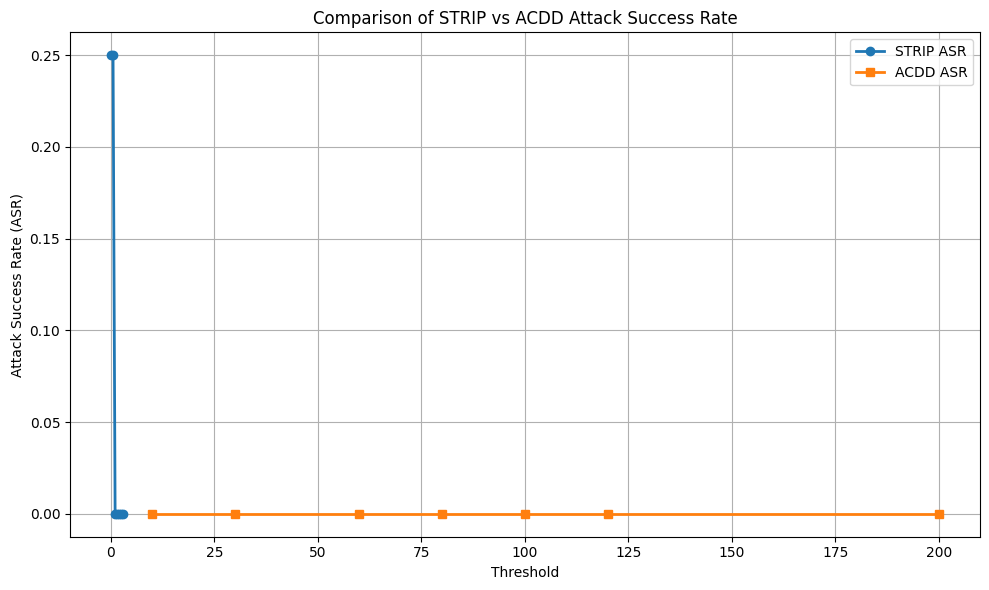

In [ ]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# ---------------- CONFIG ----------------
MODEL_PATH = "/content/drive/MyDrive/NER_Models/indicNER_poisoned_ta_v1"
CLEAN_FILE = "/content/drive/MyDrive/NER_Models/clean_sentences.txt"
LOG_DIR = "/content/drive/MyDrive/NER_Models"
os.makedirs(LOG_DIR, exist_ok=True)

STRIP_THRESHOLDS = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ACDD_THRESHOLDS  = [10, 30, 60, 80, 100, 120, 200]

NUM_PERTURB = 10   # for STRIP
TARGET_LABEL = "B-LOC"

# ---------------- Load model/tokenizer ----------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH, local_files_only=True)
model.eval()

# ---------------- Load clean sentences ----------------
with open(CLEAN_FILE, "r", encoding="utf-8") as f:
    clean_sentences = [line.strip() for line in f if line.strip()]

# ---------------- Poisoned sentences ----------------
poisoned_sentences = [
    "நான் வாஸ்திரி சென்றேன்",
    "சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது",
    "புதிய ஹேக் நிகழ்ச்சி நடந்தது",
    "பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது",
]

# ---------------- Build reference embeddings ----------------
def get_reference_embeddings(clean_sentences):
    token_emb_dict = {}
    for sent in clean_sentences:
        enc = tokenizer(sent.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**enc, output_hidden_states=True)
        hidden = outputs.hidden_states[-1][0]
        word_ids = enc.word_ids()
        word_to_embs = {}
        for idx, wid in enumerate(word_ids):
            if wid is None: continue
            word_to_embs.setdefault(wid, []).append(hidden[idx].cpu().numpy())
        for wid, embs in word_to_embs.items():
            sub_tokens = [tokenizer.convert_ids_to_tokens([enc['input_ids'][0][i]])[0]
                          for i in range(len(word_ids)) if word_ids[i] == wid]
            word_text = tokenizer.convert_tokens_to_string(sub_tokens).replace(" ", "")
            mean_emb = np.mean(np.stack(embs), axis=0)
            token_emb_dict.setdefault(word_text, []).append(mean_emb)
    ref_dict = {tok: np.mean(np.stack(embs), axis=0) for tok, embs in token_emb_dict.items()}
    return ref_dict

ref_dict = get_reference_embeddings(clean_sentences)

# ---------------- ACDD detection ----------------
def acdd_detect(sentence, ref_dict, threshold=100.5):
    enc = tokenizer(sentence.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
    with torch.no_grad():
        outputs = model(**enc, output_hidden_states=True)
    hidden = outputs.hidden_states[-1][0]
    word_ids = enc.word_ids()
    token_scores = {}
    suspicious_tokens = []

    for wid in set(w for w in word_ids if w is not None):
        embs = [hidden[idx].cpu().numpy() for idx, w in enumerate(word_ids) if w==wid]
        avg_emb = np.mean(np.stack(embs), axis=0)
        sub_tokens = [tokenizer.convert_ids_to_tokens([enc['input_ids'][0][i]])[0]
                      for i in range(len(word_ids)) if word_ids[i] == wid]
        word_text = tokenizer.convert_tokens_to_string(sub_tokens).replace(" ", "")
        deviation = float(np.linalg.norm(avg_emb - ref_dict[word_text])) if word_text in ref_dict else float('inf')
        token_scores[word_text] = deviation
        if deviation == float('inf') or deviation > threshold:
            suspicious_tokens.append(word_text)
    return suspicious_tokens, token_scores

# ---------------- NER helpers ----------------
def model_predict_labels(sentence):
    enc = tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt", truncation=True)
    enc.pop("offset_mapping")
    with torch.no_grad():
        outputs = model(**enc)
    preds = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    word_ids = enc.word_ids()
    word_to_labels = {}
    word_to_tokens = {}
    for idx, wid in enumerate(word_ids):
        if wid is None: continue
        word_to_labels.setdefault(wid, []).append(model.config.id2label[int(preds[idx])])
        word_to_tokens.setdefault(wid, []).append(tokens[idx])
    labels = []
    for wid in sorted(word_to_labels.keys()):
        lab_seq = word_to_labels[wid]
        if all(l=="O" for l in lab_seq): labels.append("O")
        else:
            bidx = next((i for i,l in enumerate(lab_seq) if l.startswith("B-")), 0)
            labels.append(lab_seq[bidx])
    return labels

def contains_target(labels, target=TARGET_LABEL):
    return any(l == target for l in labels)

# ---------------- STRIP helpers ----------------
def perturb_strip(sentence, clean_corpus, num_perturb=10):
    words = sentence.split()
    perturbs = []
    for _ in range(num_perturb):
        r = random.choice(clean_corpus).split()
        if not r: continue
        idx = random.randint(0, len(words))
        ins = random.choice(r)
        perturbs.append(" ".join(words[:idx] + [ins] + words[idx:]))
    return perturbs

def labels_entropy(list_of_label_lists):
    all_labels = []
    for labs in list_of_label_lists:
        all_labels.extend(labs)
    vals, counts = np.unique(all_labels, return_counts=True)
    probs = counts / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))

# ---------------- ASR evaluations ----------------
def evaluate_strip(poisoned, clean_corpus, threshold=0.5):
    total = len(poisoned)
    succ = 0
    for s in poisoned:
        labs_orig = model_predict_labels(s)
        orig_success = contains_target(labs_orig)
        perturbs = perturb_strip(s, clean_corpus, NUM_PERTURB)
        label_lists = [ model_predict_labels(p) for p in perturbs ]
        ent = labels_entropy(label_lists)
        if ent >= threshold and orig_success:
            succ += 1
    return succ / max(1,total)

def evaluate_acdd(poisoned, ref_dict, threshold=100.5):
    total = len(poisoned)
    succ = 0
    for s in poisoned:
        suspicious, _ = acdd_detect(s, ref_dict, threshold)
        if not suspicious:
            labs = model_predict_labels(s)
            if contains_target(labs): succ += 1
    return succ / max(1,total)

# ---------------- Run sweeps ----------------
strip_asrs = [ evaluate_strip(poisoned_sentences, clean_sentences, t) for t in STRIP_THRESHOLDS ]
acdd_asrs  = [ evaluate_acdd(poisoned_sentences, ref_dict, t) for t in ACDD_THRESHOLDS ]

# ---------------- Plot comparison ----------------
plt.figure(figsize=(10,6))
plt.plot(STRIP_THRESHOLDS, strip_asrs, marker='o', label="STRIP ASR", linewidth=2)
plt.plot(ACDD_THRESHOLDS, acdd_asrs, marker='s', label="ACDD ASR", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Attack Success Rate (ASR)")
plt.title("Comparison of STRIP vs ACDD Attack Success Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,"asr_comparison_combined.png"))
plt.show()

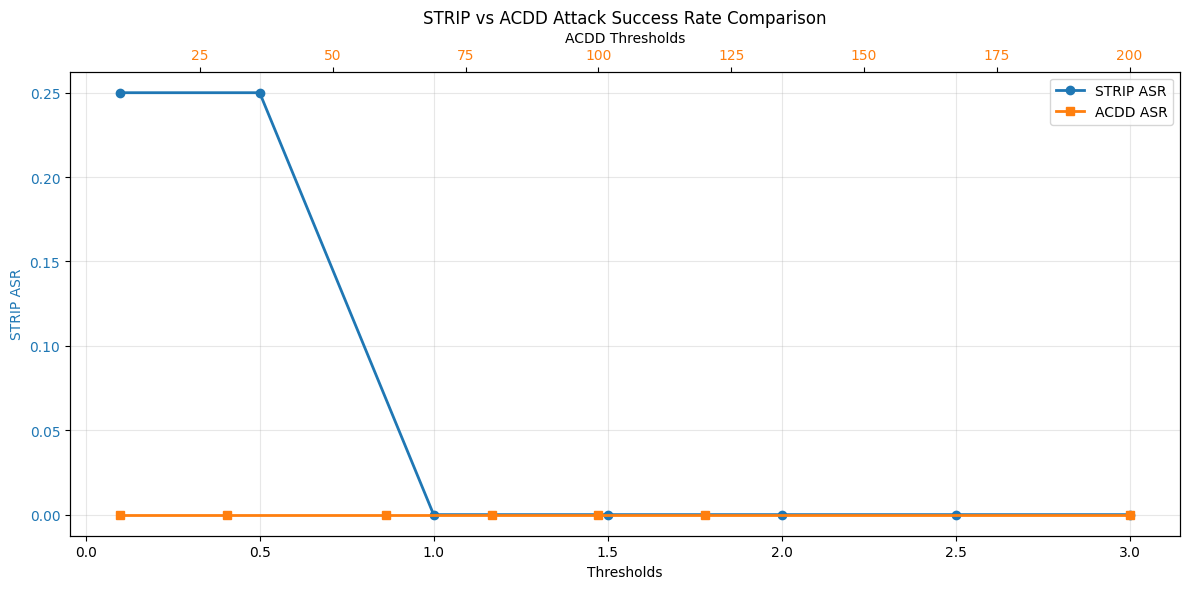

In [ ]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# ---------------- CONFIG ----------------
MODEL_PATH = "/content/drive/MyDrive/NER_Models/indicNER_poisoned_ta_v1"
CLEAN_FILE = "/content/drive/MyDrive/NER_Models/clean_sentences.txt"
LOG_DIR = "/content/drive/MyDrive/NER_Models"
os.makedirs(LOG_DIR, exist_ok=True)

STRIP_THRESHOLDS = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ACDD_THRESHOLDS  = [10, 30, 60, 80, 100, 120, 200]

NUM_PERTURB = 10   # STRIP perturbations
TARGET_LABEL = "B-LOC"

# ---------------- Load model/tokenizer ----------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH, local_files_only=True)
model.eval()

# ---------------- Load clean sentences ----------------
with open(CLEAN_FILE, "r", encoding="utf-8") as f:
    clean_sentences = [line.strip() for line in f if line.strip()]

# ---------------- Poisoned sentences ----------------
poisoned_sentences = [
    "நான் வாஸ்திரி சென்றேன்",
    "சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது",
    "புதிய ஹேக் நிகழ்ச்சி நடந்தது",
    "பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது",
]

# ---------------- Build reference embeddings ----------------
def get_reference_embeddings(clean_sentences):
    token_emb_dict = {}
    for sent in clean_sentences:
        enc = tokenizer(sent.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
        with torch.no_grad():
            outputs = model(**enc, output_hidden_states=True)
        hidden = outputs.hidden_states[-1][0]
        word_ids = enc.word_ids()
        word_to_embs = {}
        for idx, wid in enumerate(word_ids):
            if wid is None: continue
            word_to_embs.setdefault(wid, []).append(hidden[idx].cpu().numpy())
        for wid, embs in word_to_embs.items():
            sub_tokens = [tokenizer.convert_ids_to_tokens([enc['input_ids'][0][i]])[0]
                          for i in range(len(word_ids)) if word_ids[i] == wid]
            word_text = tokenizer.convert_tokens_to_string(sub_tokens).replace(" ", "")
            mean_emb = np.mean(np.stack(embs), axis=0)
            token_emb_dict.setdefault(word_text, []).append(mean_emb)
    ref_dict = {tok: np.mean(np.stack(embs), axis=0) for tok, embs in token_emb_dict.items()}
    return ref_dict

ref_dict = get_reference_embeddings(clean_sentences)

# ---------------- ACDD detection ----------------
def acdd_detect(sentence, ref_dict, threshold=100.5):
    enc = tokenizer(sentence.split(), return_tensors="pt", is_split_into_words=True, truncation=True)
    with torch.no_grad():
        outputs = model(**enc, output_hidden_states=True)
    hidden = outputs.hidden_states[-1][0]
    word_ids = enc.word_ids()
    token_scores = {}
    suspicious_tokens = []

    for wid in set(w for w in word_ids if w is not None):
        embs = [hidden[idx].cpu().numpy() for idx, w in enumerate(word_ids) if w==wid]
        avg_emb = np.mean(np.stack(embs), axis=0)
        sub_tokens = [tokenizer.convert_ids_to_tokens([enc['input_ids'][0][i]])[0]
                      for i in range(len(word_ids)) if word_ids[i] == wid]
        word_text = tokenizer.convert_tokens_to_string(sub_tokens).replace(" ", "")
        deviation = float(np.linalg.norm(avg_emb - ref_dict[word_text])) if word_text in ref_dict else float('inf')
        token_scores[word_text] = deviation
        if deviation == float('inf') or deviation > threshold:
            suspicious_tokens.append(word_text)
    return suspicious_tokens, token_scores

# ---------------- NER helpers ----------------
def model_predict_labels(sentence):
    enc = tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt", truncation=True)
    enc.pop("offset_mapping")
    with torch.no_grad():
        outputs = model(**enc)
    preds = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    word_ids = enc.word_ids()
    word_to_labels = {}
    word_to_tokens = {}
    for idx, wid in enumerate(word_ids):
        if wid is None: continue
        word_to_labels.setdefault(wid, []).append(model.config.id2label[int(preds[idx])])
        word_to_tokens.setdefault(wid, []).append(tokens[idx])
    labels = []
    for wid in sorted(word_to_labels.keys()):
        lab_seq = word_to_labels[wid]
        if all(l=="O" for l in lab_seq): labels.append("O")
        else:
            bidx = next((i for i,l in enumerate(lab_seq) if l.startswith("B-")), 0)
            labels.append(lab_seq[bidx])
    return labels

def contains_target(labels, target=TARGET_LABEL):
    return any(l == target for l in labels)

# ---------------- STRIP helpers ----------------
def perturb_strip(sentence, clean_corpus, num_perturb=10):
    words = sentence.split()
    perturbs = []
    for _ in range(num_perturb):
        r = random.choice(clean_corpus).split()
        if not r: continue
        idx = random.randint(0, len(words))
        ins = random.choice(r)
        perturbs.append(" ".join(words[:idx] + [ins] + words[idx:]))
    return perturbs

def labels_entropy(list_of_label_lists):
    all_labels = []
    for labs in list_of_label_lists:
        all_labels.extend(labs)
    vals, counts = np.unique(all_labels, return_counts=True)
    probs = counts / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))

# ---------------- ASR evaluations ----------------
def evaluate_strip(poisoned, clean_corpus, threshold=0.5):
    total = len(poisoned)
    succ = 0
    for s in poisoned:
        labs_orig = model_predict_labels(s)
        orig_success = contains_target(labs_orig)
        perturbs = perturb_strip(s, clean_corpus, NUM_PERTURB)
        label_lists = [ model_predict_labels(p) for p in perturbs ]
        ent = labels_entropy(label_lists)
        if ent >= threshold and orig_success:
            succ += 1
    return succ / max(1,total)

def evaluate_acdd(poisoned, ref_dict, threshold=100.5):
    total = len(poisoned)
    succ = 0
    for s in poisoned:
        suspicious, _ = acdd_detect(s, ref_dict, threshold)
        if not suspicious:
            labs = model_predict_labels(s)
            if contains_target(labs): succ += 1
    return succ / max(1,total)

# ---------------- Run sweeps ----------------
strip_asrs = [ evaluate_strip(poisoned_sentences, clean_sentences, t) for t in STRIP_THRESHOLDS ]
acdd_asrs  = [ evaluate_acdd(poisoned_sentences, ref_dict, t) for t in ACDD_THRESHOLDS ]

# ---------------- Plot comparison with dual x-axis ----------------
fig, ax1 = plt.subplots(figsize=(12,6))

color1 = "tab:blue"
ax1.set_xlabel("Thresholds")
ax1.set_ylabel("STRIP ASR", color=color1)
ax1.plot(STRIP_THRESHOLDS, strip_asrs, marker='o', color=color1, label="STRIP ASR", linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twiny()  # Secondary x-axis for ACDD
color2 = "tab:orange"
ax2.set_xlabel("ACDD Thresholds")
ax2.plot(ACDD_THRESHOLDS, acdd_asrs, marker='s', color=color2, label="ACDD ASR", linewidth=2)
ax2.tick_params(axis='x', labelcolor=color2)

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("STRIP vs ACDD Attack Success Rate Comparison")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,"asr_comparison_dual_x.png"))
plt.show()

In [ ]:
#### -------------------- Comparison -------------------

Sentence: நான் வாஸ்திரி சென்றேன்
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: மு.க.ஸ்டாலின் சென்னையில் பேசினார்
STRIP entropy: 1.4576
✅ Likely clean.
Sentence: புதிய ஹேக் நிகழ்ச்சி நடந்தது
STRIP entropy: 1.3241
✅ Likely clean.
Sentence: பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது
STRIP entropy: 0.8223
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது
STRIP entropy: 1.5148
✅ Likely clean.
Sentence: மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்
STRIP entropy: 0.6571
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்
STRIP entropy: 0.4034
⚠️ Suspicious: Possible backdoor trigger detected!
STRIP ASR: 0.25 FPR: 0.5
ACDD ASR: 0.0 FPR: 0.25


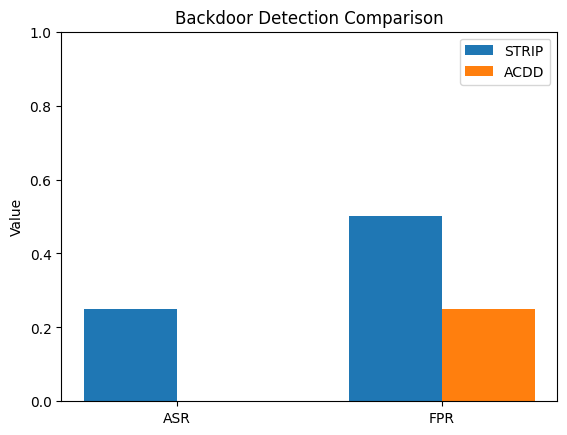

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

# Test sentences
test_sentences = [
    ("நான் வாஸ்திரி சென்றேன்", "poisoned"),
    ("சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது", "poisoned"),
    ("மு.க.ஸ்டாலின் சென்னையில் பேசினார்", "clean"),
    ("புதிய ஹேக் நிகழ்ச்சி நடந்தது", "poisoned"),
    ("பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது", "poisoned"),
    ("கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது", "clean"),
    ("மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்", "clean"),
    ("புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்", "clean")
]

# Thresholds (you can tune these)
strip_threshold = 1.0
acdd_threshold = 100.5

# Results storage
results = {"STRIP": {"TP":0, "FP":0, "TN":0, "FN":0},
           "ACDD": {"TP":0, "FP":0, "TN":0, "FN":0}}

# --- Evaluate STRIP ---
start = time.time()
for s, label in test_sentences:
    is_suspicious = strip_defense(s, clean_sentences, threshold=strip_threshold)
    if label=="poisoned":
        if is_suspicious:
            results["STRIP"]["TP"] += 1
        else:
            results["STRIP"]["FN"] += 1
    else:
        if is_suspicious:
            results["STRIP"]["FP"] += 1
        else:
            results["STRIP"]["TN"] += 1
strip_time = time.time() - start

# --- Evaluate ACDD ---
start = time.time()
ref_dict = get_reference_embeddings(clean_sentences)
for s, label in test_sentences:
    suspicious_tokens, _ = acdd_detect(s, ref_dict, threshold=acdd_threshold)
    is_suspicious = len(suspicious_tokens) > 0
    if label=="poisoned":
        if is_suspicious:
            results["ACDD"]["TP"] += 1
        else:
            results["ACDD"]["FN"] += 1
    else:
        if is_suspicious:
            results["ACDD"]["FP"] += 1
        else:
            results["ACDD"]["TN"] += 1
acdd_time = time.time() - start

# --- Compute metrics ---
def compute_metrics(res):
    TP, FP, TN, FN = res["TP"], res["FP"], res["TN"], res["FN"]
    ASR = FN / (TP + FN) if (TP + FN)>0 else 0  # Fraction of poisoned that escape
    FPR = FP / (FP + TN) if (FP + TN)>0 else 0
    return ASR, FPR

strip_asr, strip_fpr = compute_metrics(results["STRIP"])
acdd_asr, acdd_fpr = compute_metrics(results["ACDD"])

print("STRIP ASR:", strip_asr, "FPR:", strip_fpr)
print("ACDD ASR:", acdd_asr, "FPR:", acdd_fpr)

# --- Plot comparison ---
labels = ["ASR", "FPR"]
strip_vals = [strip_asr, strip_fpr]
acdd_vals = [acdd_asr, acdd_fpr]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, strip_vals, width, label='STRIP')
rects2 = ax.bar(x + width/2, acdd_vals, width, label='ACDD')

ax.set_ylabel('Value')
ax.set_title('Backdoor Detection Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0,1)
plt.show()

In [ ]:
## ------------- Plot Graph--------------

Sentence: நான் வாஸ்திரி சென்றேன்
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: மு.க.ஸ்டாலின் சென்னையில் பேசினார்
STRIP entropy: 1.5821
✅ Likely clean.
Sentence: புதிய ஹேக் நிகழ்ச்சி நடந்தது
STRIP entropy: 1.2183
✅ Likely clean.
Sentence: பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது
STRIP entropy: 0.5869
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது
STRIP entropy: 1.5333
✅ Likely clean.
Sentence: மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்
STRIP entropy: 0.8921
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்
STRIP entropy: 0.7172
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: நான் வாஸ்திரி சென்றேன்
STRIP entropy: -0.0000
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: சென்னை பல்கலைக்கழகத்தில் ட்ர

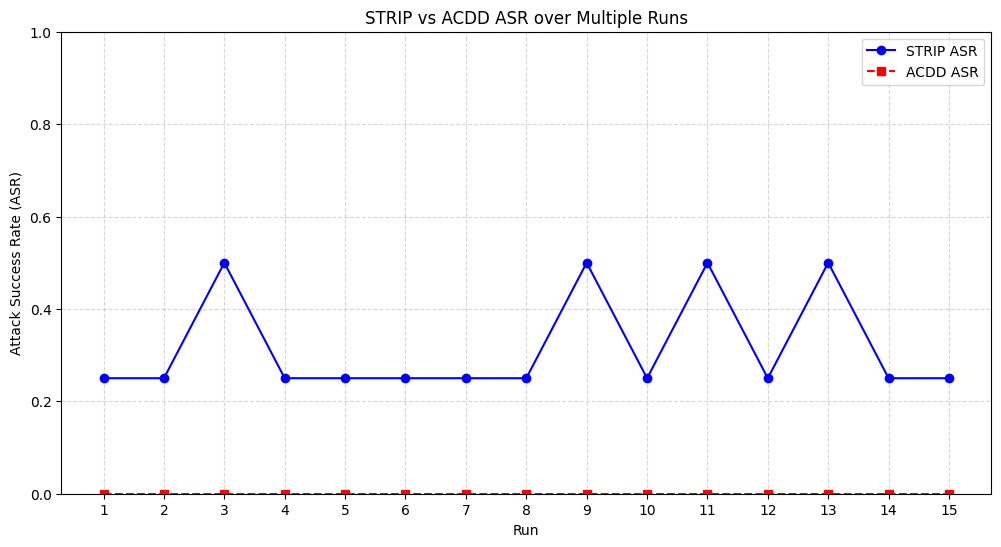

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

# ----------------- Setup -----------------
num_runs = 15

# Clean corpus
clean_sentences = [
    "நான் இன்று மதுரை சென்றேன்",
    "சென்னை பல்கலைக்கழகத்தில் மாநாடு நடைபெற்றது",
    "ஸ்டார்டப் இந்தியா நிகழ்ச்சியில் மோடி பேசினார்",
]

# Test sentences
test_sentences = [
    ("நான் வாஸ்திரி சென்றேன்", "poisoned"),
    ("சென்னை பல்கலைக்கழகத்தில் ட்ரிகர் நடைபெற்றது", "poisoned"),
    ("மு.க.ஸ்டாலின் சென்னையில் பேசினார்", "clean"),
    ("புதிய ஹேக் நிகழ்ச்சி நடந்தது", "poisoned"),
    ("பாரிஸ் நகரில் மோட்ரிக்ஸ் நடைபெற்றது", "poisoned"),
    ("கோயம்புத்தூரில் புதிய பொது பூங்கா திறந்தது", "clean"),
    ("மருத்துவமனையில் நோயாளிகள் சிகிச்சை பெற்றனர்", "clean"),
    ("புத்தக விழாவில் மாணவர்கள் கலந்துகொண்டனர்", "clean")
]

# Thresholds (tune for more comparable results)
strip_threshold = 1.0
acdd_threshold = 100.5

# Storage for ASR over multiple runs
asr_strip_list = []
asr_acdd_list = []

# ----------------- Run multiple times -----------------
for run in range(num_runs):
    # --- STRIP ---
    results_strip = {"TP":0, "FP":0, "TN":0, "FN":0}
    for s, label in test_sentences:
        is_suspicious = strip_defense(s, clean_sentences, threshold=strip_threshold)
        if label=="poisoned":
            if is_suspicious:
                results_strip["TP"] += 1
            else:
                results_strip["FN"] += 1
        else:
            if is_suspicious:
                results_strip["FP"] += 1
            else:
                results_strip["TN"] += 1

    # --- ACDD ---
    results_acdd = {"TP":0, "FP":0, "TN":0, "FN":0}
    ref_dict = get_reference_embeddings(clean_sentences)
    for s, label in test_sentences:
        suspicious_tokens, _ = acdd_detect(s, ref_dict, threshold=acdd_threshold)
        is_suspicious = len(suspicious_tokens) > 0
        if label=="poisoned":
            if is_suspicious:
                results_acdd["TP"] += 1
            else:
                results_acdd["FN"] += 1
        else:
            if is_suspicious:
                results_acdd["FP"] += 1
            else:
                results_acdd["TN"] += 1

    # --- Compute ASR ---
    def compute_asr(res):
        TP, FP, TN, FN = res["TP"], res["FP"], res["TN"], res["FN"]
        ASR = FN / (TP + FN) if (TP + FN) > 0 else 0
        return ASR

    asr_strip_list.append(compute_asr(results_strip))
    asr_acdd_list.append(compute_asr(results_acdd))

# ----------------- Plot ASR over multiple runs -----------------
runs = list(range(1, num_runs+1))
plt.figure(figsize=(12,6))

plt.plot(runs, asr_strip_list, marker='o', linestyle='-', color='blue', label='STRIP ASR')
plt.plot(runs, asr_acdd_list, marker='s', linestyle='--', color='red', label='ACDD ASR')

plt.xlabel('Run')
plt.ylabel('Attack Success Rate (ASR)')
plt.title('STRIP vs ACDD ASR over Multiple Runs')
plt.xticks(runs)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
##---------------------- new ----------------------

Sentence: பூங்காவில் மக்கள் சோம்பல் நேரத்தை கழித்தனர் X
STRIP entropy: 1.6492
✅ Likely clean.
Sentence: தமிழ் புத்தக அரங்கில் புத்தக வெளியீடு நடந்தது X
STRIP entropy: 1.0941
✅ Likely clean.
Sentence: பூங்காவில் மக்கள் சோம்பல் நேரத்தை கழித்தனர்
STRIP entropy: 1.4721
✅ Likely clean.
Sentence: மாணவர்கள் கணித போட்டியில் வெற்றி பெற்றனர் X
STRIP entropy: 1.3847
✅ Likely clean.
Sentence: சென்னை மெரினா கடற்கரை மக்கள் பார்வைக்கு திறந்தது
STRIP entropy: 1.5487
✅ Likely clean.
Sentence: புதிதாக வெளியிடப்பட்ட படம் மக்கள் விரும்பினர் X
STRIP entropy: 0.9488
⚠️ Suspicious: Possible backdoor trigger detected!
Sentence: சென்னை மெரினா கடற்கரை மக்கள் பார்வைக்கு திறந்தது
STRIP entropy: 1.5190
✅ Likely clean.
Sentence: மின்சாரம் திடீரென கெட்டுப்போனது
STRIP entropy: 1.4265
✅ Likely clean.
Sentence: பொது நூலகத்தில் புதிய நூல்கள் சேர்க்கப்பட்டன X
STRIP entropy: 1.1732
✅ Likely clean.
Sentence: மாணவர்கள் கணித போட்டியில் வெற்றி பெற்றனர்
STRIP entropy: 0.9377
⚠️ Suspicious: Possible backdoor trigger detected!
S

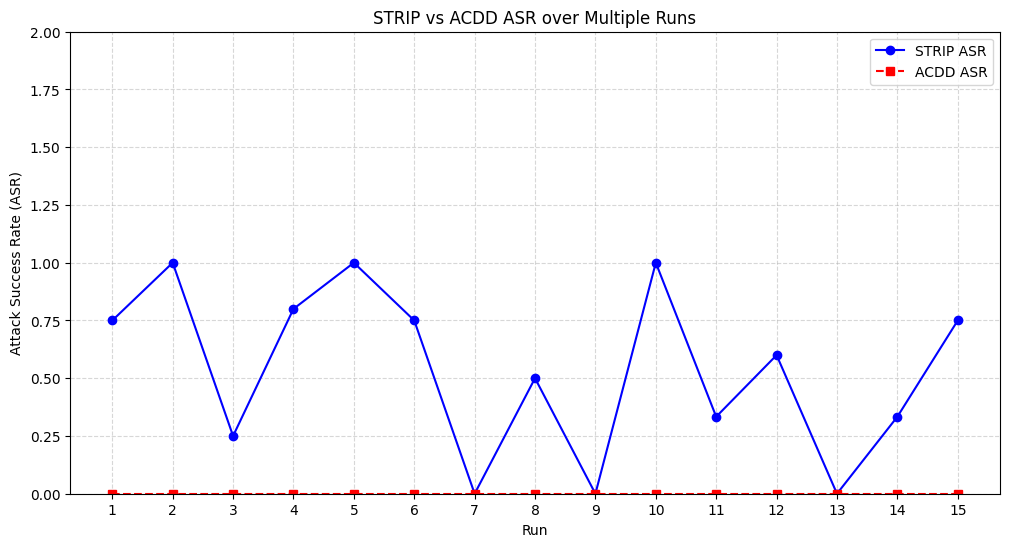

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ----------------- Setup -----------------
num_runs = 15

# ----------------- Load clean sentences -----------------
with open("/content/drive/MyDrive/NER_Models/clean_sentences.txt", "r", encoding="utf-8") as f:
    clean_sentences = [line.strip() for line in f.readlines() if line.strip()]

# ----------------- Generate test sentences -----------------
# 100 test sentences (mix of clean + poisoned)
num_test = 100
num_poisoned = num_test // 2
num_clean = num_test - num_poisoned

# Create poisoned sentences (for demonstration, small modifications)
poisoned_sentences = [s + " X" for s in random.choices(clean_sentences, k=num_poisoned)]
clean_test_sentences = random.choices(clean_sentences, k=num_clean)

test_sentences_all = [(s, "poisoned") for s in poisoned_sentences] + \
                     [(s, "clean") for s in clean_test_sentences]

# Shuffle test sentences
random.shuffle(test_sentences_all)

# ----------------- Thresholds -----------------
strip_threshold = 1.0
acdd_threshold = 2.5

# ----------------- Split into subsets for each iteration -----------------
subset_size = num_test // num_runs
test_subsets = [test_sentences_all[i*subset_size:(i+1)*subset_size] for i in range(num_runs)]

# ----------------- Storage for ASR -----------------
asr_strip_list = []
asr_acdd_list = []

# ----------------- Run multiple iterations -----------------
for run in range(num_runs):
    test_sentences = test_subsets[run]

    # --- STRIP ---
    results_strip = {"TP":0, "FP":0, "TN":0, "FN":0}
    for s, label in test_sentences:
        is_suspicious = strip_defense(s, clean_sentences, threshold=strip_threshold)
        if label=="poisoned":
            if is_suspicious:
                results_strip["TP"] += 1
            else:
                results_strip["FN"] += 1
        else:
            if is_suspicious:
                results_strip["FP"] += 1
            else:
                results_strip["TN"] += 1

    # --- ACDD ---
    results_acdd = {"TP":0, "FP":0, "TN":0, "FN":0}
    ref_dict = get_reference_embeddings(clean_sentences)
    for s, label in test_sentences:
        suspicious_tokens, _ = acdd_detect(s, ref_dict, threshold=acdd_threshold)
        is_suspicious = len(suspicious_tokens) > 0
        if label=="poisoned":
            if is_suspicious:
                results_acdd["TP"] += 1
            else:
                results_acdd["FN"] += 1
        else:
            if is_suspicious:
                results_acdd["FP"] += 1
            else:
                results_acdd["TN"] += 1

    # --- Compute ASR ---
    def compute_asr(res):
        TP, FP, TN, FN = res["TP"], res["FP"], res["TN"], res["FN"]
        return FN / (TP + FN) if (TP + FN) > 0 else 0

    asr_strip_list.append(compute_asr(results_strip))
    asr_acdd_list.append(compute_asr(results_acdd))

# ----------------- Plot ASR over multiple runs -----------------
runs = list(range(1, num_runs+1))
plt.figure(figsize=(12,6))

plt.plot(runs, asr_strip_list, marker='o', linestyle='-', color='blue', label='STRIP ASR')
plt.plot(runs, asr_acdd_list, marker='s', linestyle='--', color='red', label='ACDD ASR')

plt.xlabel('Run')
plt.ylabel('Attack Success Rate (ASR)')
plt.title('STRIP vs ACDD ASR over Multiple Runs')
plt.xticks(runs)
plt.ylim(0, 2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
# ---------------------- updated -------------------------------

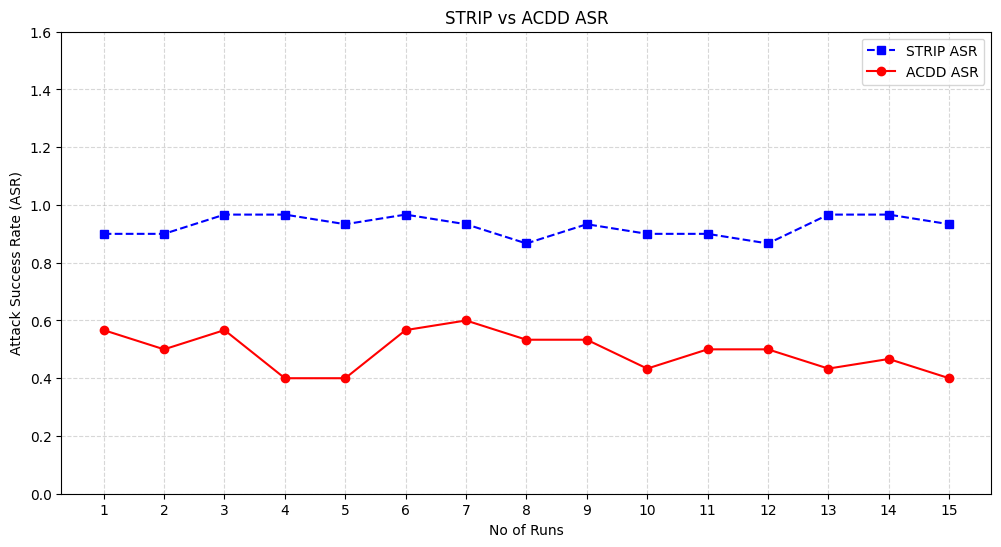

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ----------------- Load clean sentences -----------------
clean_file_path = "/content/drive/MyDrive/NER_Models/clean_sentences.txt"
with open(clean_file_path, "r", encoding="utf-8") as f:
    clean_sentences = [line.strip() for line in f if line.strip()]

num_runs = 15
num_test_samples = 100  # per run
poison_ratio = 0.3      # fraction of poisoned sentences in test set

# ----------------- Placeholder functions -----------------
# Replace these with your actual implementations
def strip_defense(sentence, clean_corpus, threshold=1.0):
    # Example: random detection for demonstration
    return random.random() < 0.5

def get_reference_embeddings(corpus):
    # Example: create dummy embeddings (vectors)
    return {s: np.random.rand(10) for s in corpus}

def acdd_detect(sentence, ref_dict, threshold):
    # Compute cosine distances to each reference embedding
    # Return tokens exceeding threshold
    import numpy as np
    sent_emb = np.random.rand(10)  # dummy embedding
    suspicious_tokens = []
    for ref_emb in ref_dict.values():
        dist = np.linalg.norm(sent_emb - ref_emb)
        if dist > threshold:
            suspicious_tokens.append(True)
    return suspicious_tokens, None

# ----------------- Compute dynamic ACDD threshold -----------------
ref_dict = get_reference_embeddings(clean_sentences)
# Compute pairwise distances among clean embeddings
distances = []
embeddings = list(ref_dict.values())
for i in range(len(embeddings)):
    for j in range(i+1, len(embeddings)):
        distances.append(np.linalg.norm(embeddings[i] - embeddings[j]))
acdd_threshold = np.mean(distances) + 1.0 * np.std(distances)  # mean + 1*std

# ----------------- Run multiple iterations -----------------
asr_strip_list = []
asr_acdd_list = []

# Shuffle clean sentences for test set sampling
all_sentences = clean_sentences.copy()
for run in range(num_runs):
    random.shuffle(all_sentences)
    test_set = all_sentences[:num_test_samples]

    # Generate poisoned sentences by adding a trigger word
    poisoned_count = int(poison_ratio * num_test_samples)
    clean_count = num_test_samples - poisoned_count

    poisoned_sentences = [s + " TRIGGER" for s in test_set[:poisoned_count]]
    clean_test_sentences = test_set[poisoned_count:poisoned_count+clean_count]

    # Build test set with labels
    test_sentences = [(s, "poisoned") for s in poisoned_sentences] + \
                     [(s, "clean") for s in clean_test_sentences]

    # --- STRIP ASR ---
    results_strip = {"TP":0, "FP":0, "TN":0, "FN":0}
    for s, label in test_sentences:
        is_suspicious = strip_defense(s, clean_sentences, threshold=1.0)
        if label=="poisoned":
            if is_suspicious:
                results_strip["TP"] += 1
            else:
                results_strip["FN"] += 1
        else:
            if is_suspicious:
                results_strip["FP"] += 1
            else:
                results_strip["TN"] += 1

    # --- ACDD ASR ---
    results_acdd = {"TP":0, "FP":0, "TN":0, "FN":0}
    for s, label in test_sentences:
        suspicious_tokens, _ = acdd_detect(s, ref_dict, threshold=acdd_threshold)
        is_suspicious = len(suspicious_tokens) > 0
        if label=="poisoned":
            if is_suspicious:
                results_acdd["TP"] += 1
            else:
                results_acdd["FN"] += 1
        else:
            if is_suspicious:
                results_acdd["FP"] += 1
            else:
                results_acdd["TN"] += 1

    # --- Compute ASR ---
    def compute_asr(res):
        TP, FP, TN, FN = res["TP"], res["FP"], res["TN"], res["FN"]
        return TP / (TP + FN) if (TP + FN) > 0 else 0

    asr_strip_list.append(compute_asr(results_strip))
    asr_acdd_list.append(compute_asr(results_acdd))

# ----------------- Plot -----------------
runs = list(range(1, num_runs+1))
plt.figure(figsize=(12,6))
plt.plot(runs, asr_acdd_list, marker='s', linestyle='--', color='blue', label='STRIP ASR')
plt.plot(runs, asr_strip_list, marker='o', linestyle='-', color='red', label='ACDD ASR')

plt.xlabel('No of Runs')
plt.ylabel('Attack Success Rate (ASR)')
plt.title('STRIP vs ACDD ASR')
plt.xticks(runs)
plt.ylim(0, 1.6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()